
# Fast Pseudo-Voigt laser image mixer with empty-template recentering

This version avoids fitting every image column. Each template is mapped back into the unrotated laser rectangle, collapsed across length with:

```python
profile = np.median(template_rect, axis=-1)
```

The important change is that the empty template can be fitted from a padded row crop, then rebuilt with its fitted center moved to the same center as the full/reference template. This handles the case where the empty-template laser is shifted relative to every other image.

Default mask meaning: `True -> empty template fit`, `False -> full template fit`.


In [ ]:

from pathlib import Path
import time
import numpy as np
import cv2
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit, least_squares

# Uploaded test image
TEST_IMAGE_PATH = Path(r"C:\Users\dhruv\Documents\dhruv_python\disc2accurate\frame_2264_t_6010.464009_x_181.189021_y_131.222021_z_0.119732.jpg")

# Constants copied from make_laser_image.py
RECT_ROW0 = 160      # x in make_laser_image.py, but used as a row index
RECT_COL0 = 210      # y in make_laser_image.py, but used as a col index
LASER_W = 80
LASER_L = 425
CANVAS_SHAPE = (640, 640)     # pre-rotation canvas, rows x cols
OUT_SIZE = (640, 480)         # cv2 warpAffine dsize: width x height
ROT_CENTER = (420, 240)       # OpenCV center: x, y
ROT_ANGLE_DEG = -(270 + 26.2)

ROT_M = cv2.getRotationMatrix2D(ROT_CENTER, ROT_ANGLE_DEG, 1)
INV_ROT_M = cv2.invertAffineTransform(ROT_M)


## Pseudo-Voigt fit

In [ ]:

def pseudo_voigt_profile(x, A, x0, sigma, gamma, p, B):
    """A * [p * Lorentz + (1-p) * Gaussian] + B. Both components peak at 1."""
    x = np.asarray(x, dtype=float)
    sigma = max(float(sigma), 1e-6)
    gamma = max(float(gamma), 1e-6)
    gauss = np.exp(-0.5 * ((x - x0) / sigma) ** 2)
    lorentz = 1.0 / (1.0 + ((x - x0) / gamma) ** 2)
    return A * (p * lorentz + (1.0 - p) * gauss) + B


def pseudo_voigt_fit(x, y, p0=None, bounds=None, method='robust', robust_loss='huber', robust_f_scale=3.0):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    if x.shape != y.shape:
        raise ValueError('x and y must have the same shape')

    y_min, y_max = float(y.min()), float(y.max())
    A0 = max(y_max - y_min, 1e-6)
    x0_0 = float(x[np.argmax(y)])
    weights = np.maximum(y - y_min, 0)
    sigma0 = np.sqrt(np.sum((x - x0_0) ** 2 * weights) / (weights.sum() + 1e-12))
    p0 = [A0, x0_0, max(float(sigma0), 1.0), max(float(sigma0) / 2, 1.0), 0.5, y_min] if p0 is None else p0

    if bounds is None:
        span = float(x.max() - x.min())
        bounds = ([0, x.min(), 0.1, 0.1, 0, y_min - A0],
                  [np.inf, x.max(), 2 * span, 2 * span, 1, y_max + A0])

    lb, ub = np.asarray(bounds[0], float), np.asarray(bounds[1], float)
    p0 = np.clip(np.asarray(p0, float), lb, ub)

    try:
        if method == 'robust':
            res = least_squares(lambda q: pseudo_voigt_profile(x, *q) - y,
                                p0, bounds=(lb, ub), loss=robust_loss,
                                f_scale=robust_f_scale, max_nfev=20_000)
            popt, pcov, success, msg = res.x, None, bool(res.success), str(res.message)
        elif method == 'lsq':
            popt, pcov = curve_fit(pseudo_voigt_profile, x, y, p0=p0,
                                   bounds=bounds, maxfev=20_000)
            success, msg = True, 'curve_fit converged'
        else:
            raise ValueError("method must be 'robust' or 'lsq'")
    except Exception as e:
        popt, pcov, success, msg = p0, None, False, f'fit failed: {e}'

    model = lambda xx: pseudo_voigt_profile(np.asarray(xx, dtype=float), *popt)
    sigma, gamma, p = popt[2], popt[3], popt[4]
    fwhm = p * (2 * gamma) + (1 - p) * (2 * np.sqrt(2 * np.log(2)) * sigma)
    return {'params': popt, 'param_cov': pcov, 'fwhm': float(fwhm),
            'model': model, 'residuals': y - model(x),
            'success': success, 'message': msg}


## Fast median-profile laser fitting

In [ ]:

def read_gray(img_or_path):
    if isinstance(img_or_path, (str, Path)):
        img = cv2.imread(str(img_or_path), cv2.IMREAD_GRAYSCALE)
        if img is None:
            raise FileNotFoundError(img_or_path)
        return img
    img = np.asarray(img_or_path)
    return cv2.cvtColor(img, cv2.COLOR_BGR2GRAY) if img.ndim == 4 else img.copy()


def unrotate_to_canvas(img):
    """Map output image coordinates back into the pre-rotation 640x640 canvas."""
    return cv2.warpAffine(read_gray(img), INV_ROT_M,
                          (CANVAS_SHAPE[1], CANVAS_SHAPE[0]),
                          flags=cv2.INTER_LINEAR, borderValue=0)


def rotate_canvas_to_output(canvas, interpolation=cv2.INTER_LINEAR):
    return cv2.warpAffine(canvas, ROT_M, OUT_SIZE, flags=interpolation, borderValue=0)


def canonical_rect_from_canvas(canvas):
    return canvas[RECT_ROW0:RECT_ROW0 + LASER_W, RECT_COL0:RECT_COL0 + LASER_L]


def padded_rect_from_template(img, row_pad=0):
    """
    Return a row-padded unrotated crop so a shifted laser can still be fitted.

    x_pad is in unrotated canvas row coordinates, not local 0..LASER_W coordinates.
    """
    canvas = unrotate_to_canvas(img)
    row_pad = int(row_pad)
    r1 = max(0, RECT_ROW0 - row_pad)
    r2 = min(CANVAS_SHAPE[0], RECT_ROW0 + LASER_W + row_pad)
    c1, c2 = RECT_COL0, RECT_COL0 + LASER_L
    return canvas[r1:r2, c1:c2], np.arange(r1, r2, dtype=float), canvas


def fit_template_median_profile(img, reducer=np.median, method='robust',
                                robust_loss='huber', robust_f_scale=4.0,
                                row_pad=0, target_center=None):
    """
    Fit one pseudo-Voigt profile to one template image.

    If target_center is set, the template is fitted at its true measured center,
    but the reconstructed fit profile is rebuilt with x0 moved to target_center.
    This keeps the empty template's width/shape/amplitude while placing its laser
    center in the same spot as the reference/full images.
    """
    rect_pad, x_pad, canvas = padded_rect_from_template(img, row_pad=row_pad)
    rect_pad = rect_pad.astype(float)
    profile = reducer(rect_pad, axis=-1)

    fit = pseudo_voigt_fit(x_pad, profile, method=method,
                           robust_loss=robust_loss, robust_f_scale=robust_f_scale)

    measured_params = fit['params'].copy()
    aligned_params = measured_params.copy()
    measured_center = float(measured_params[1])

    if target_center is not None:
        aligned_params[1] = float(target_center)

    x_canon = np.arange(RECT_ROW0, RECT_ROW0 + LASER_W, dtype=float)
    fit_profile = pseudo_voigt_profile(x_canon, *aligned_params)
    fit_rect = np.repeat(fit_profile[:, None], LASER_L, axis=1)

    return {
        'rect': canonical_rect_from_canvas(canvas).astype(float),
        'rect_pad': rect_pad,
        'x_pad': x_pad,
        'x_canon': x_canon,
        'profile': profile,
        'fit_profile': fit_profile,
        'fit_rect': fit_rect,
        'fit': fit,
        'measured_params': measured_params,
        'aligned_params': aligned_params,
        'measured_center': measured_center,
        'target_center': None if target_center is None else float(target_center),
        'center_shift_applied': 0.0 if target_center is None else float(target_center - measured_center),
    }


def rotate_local_mask(local_mask_wl):
    local_mask_wl = np.asarray(local_mask_wl, dtype=bool)
    if local_mask_wl.shape != (LASER_W, LASER_L):
        raise ValueError(f'local mask must have shape {(LASER_W, LASER_L)}, got {local_mask_wl.shape}')
    canvas = np.zeros(CANVAS_SHAPE, dtype=np.uint8)
    canvas[RECT_ROW0:RECT_ROW0 + LASER_W, RECT_COL0:RECT_COL0 + LASER_L] = local_mask_wl.astype(np.uint8)
    return rotate_canvas_to_output(canvas, interpolation=cv2.INTER_NEAREST).astype(bool)


def laser_roi_mask():
    return rotate_local_mask(np.ones((LASER_W, LASER_L), dtype=bool))


In [ ]:

def make_laser_image(local_mask_wl, empty_template_img, full_template_img,
                     mask_true='empty', reducer=np.median, background='zeros',
                     fit_cache=None, return_debug=False,
                     empty_row_pad=35, full_row_pad=0,
                     align_empty_to_full=True, target_empty_center=None):
    """
    Build a laser image from two median-profile pseudo-Voigt fits.

    Parameters
    ----------
    local_mask_wl : bool ndarray, shape (LASER_W, LASER_L)
        Local mask in unrotated laser rectangle coordinates.
    empty_template_img, full_template_img : path or ndarray
        Template images. They are unrotated internally before taking median(axis=-1).
    mask_true : {'empty', 'full'}
        True pixels use the selected template fit.
    reducer : callable
        Function like np.median or np.mean. It must accept axis=-1.
    empty_row_pad : int
        Extra rows above/below the canonical laser rectangle used only while fitting
        the empty template. Increase this if the empty-template laser is farther off.
    full_row_pad : int
        Usually 0 because all non-empty images share the canonical laser position.
    align_empty_to_full : bool
        If True, fit the full/reference image first and force the empty fit's center
        to the full fit's measured center.
    target_empty_center : float or None
        Optional manual target center in unrotated canvas row coordinates. Overrides
        the full fit center when provided.
    """
    local_mask_wl = np.asarray(local_mask_wl, dtype=bool)
    if local_mask_wl.shape != (LASER_W, LASER_L):
        raise ValueError(f'local mask must have shape {(LASER_W, LASER_L)}, got {local_mask_wl.shape}')

    empty = read_gray(empty_template_img)
    full = read_gray(full_template_img)
    if empty.shape != full.shape:
        raise ValueError(f'empty/full shapes differ: {empty.shape} vs {full.shape}')

    fit_cache = {} if fit_cache is None else fit_cache

    def cache_key(name, img, row_pad, target_center):
        return (name, img.shape, img.dtype.str,
                round(float(img.mean()), 6), round(float(img.std()), 6),
                getattr(reducer, '__name__', str(reducer)), int(row_pad),
                None if target_center is None else round(float(target_center), 6))

    def get_fit(name, img, row_pad=0, target_center=None):
        key = cache_key(name, img, row_pad, target_center)
        if key not in fit_cache:
            fit_cache[key] = fit_template_median_profile(
                img, reducer=reducer, row_pad=row_pad, target_center=target_center
            )
        return fit_cache[key]

    # Fit the full/reference image first. This defines the center used by all normal images.
    full_fit = get_fit('full', full, row_pad=full_row_pad, target_center=None)

    target_center = target_empty_center
    if align_empty_to_full and target_center is None:
        target_center = full_fit['measured_center']

    empty_fit = get_fit('empty', empty, row_pad=empty_row_pad, target_center=target_center)

    if mask_true == 'empty':
        local_out = np.where(local_mask_wl, empty_fit['fit_rect'], full_fit['fit_rect'])
    elif mask_true == 'full':
        local_out = np.where(local_mask_wl, full_fit['fit_rect'], empty_fit['fit_rect'])
    else:
        raise ValueError("mask_true must be 'empty' or 'full'")

    canvas = np.zeros(CANVAS_SHAPE, dtype=float)
    canvas[RECT_ROW0:RECT_ROW0 + LASER_W, RECT_COL0:RECT_COL0 + LASER_L] = local_out
    fitted_output = rotate_canvas_to_output(canvas, interpolation=cv2.INTER_LINEAR)
    roi = laser_roi_mask()

    if background == 'zeros':
        out = fitted_output
    elif background == 'empty_template':
        out = empty.astype(float).copy()
        out[roi] = fitted_output[roi]
    else:
        out = np.asarray(background, dtype=float).copy()
        if out.shape != empty.shape:
            raise ValueError('background ndarray must match template image shape')
        out[roi] = fitted_output[roi]

    out_u8 = np.clip(out, 0, 255).astype(np.uint8)
    if return_debug:
        return out_u8, {'empty_fit': empty_fit, 'full_fit': full_fit,
                        'local_out': local_out, 'fitted_output': fitted_output,
                        'laser_roi': roi, 'rotated_mask': rotate_local_mask(local_mask_wl),
                        'fit_cache': fit_cache}
    return out_u8


## Test and compare with the uploaded image

In [ ]:

# Smoke test: using the uploaded image as both templates verifies the geometry + fit path.
# Replace these paths with real empty/full templates when available.
empty_template = Path(r"C:\Users\dhruv\Documents\dhruv_python\disc2accurate\frame_2419_t_6020.320204_x_193.516000_y_105.383861_z_1.086427.jpg")
full_template = Path(r"C:\Users\dhruv\Documents\dhruv_python\disc2accurate\frame_2405_t_6019.452248_x_180.866510_y_141.850812_z_0.129810.jpg")

frame = read_gray(TEST_IMAGE_PATH)
from filament_array import extract_filament_array
test_mask, pre = extract_filament_array(img_i = 2264-149)
#pad from (40, 285) to (80, 325)
test_mask = np.pad(test_mask, (20, 20), mode='constant', constant_values=False)
# With mask_true='full', this all-True mask means use the full fit everywhere.
local_mask = np.ones((LASER_W, LASER_L), dtype=bool)
cache = {}

t0 = time.perf_counter()
made, dbg = make_laser_image(test_mask, empty_template, full_template,
                             mask_true='empty', background='zeros',
                             fit_cache=cache, return_debug=True,
                             empty_row_pad=35, align_empty_to_full=True)
dt = time.perf_counter() - t0

roi = dbg['laser_roi']
frame_roi = np.where(roi, frame, 0).astype(np.uint8)
diff = made.astype(float) - frame_roi.astype(float)

print(f'make_laser_image time: {dt:.4f} s')
print('image shape:', frame.shape)
print('laser ROI pixels:', int(roi.sum()))
print('full fit success:', dbg['full_fit']['fit']['success'])
print('empty fit success:', dbg['empty_fit']['fit']['success'])
print('full measured center:', round(dbg['full_fit']['measured_center'], 3))
print('empty measured center:', round(dbg['empty_fit']['measured_center'], 3))
print('empty target center:', None if dbg['empty_fit']['target_center'] is None else round(dbg['empty_fit']['target_center'], 3))
print('empty shift applied:', round(dbg['empty_fit']['center_shift_applied'], 3))
print('full fit params [A, x0, sigma, gamma, p, B]:')
print(np.round(dbg['full_fit']['fit']['params'], 3))
print('ROI MAE:', np.mean(np.abs(diff[roi])))
print('ROI RMSE:', np.sqrt(np.mean(diff[roi] ** 2)))


make_laser_image time: 23.5877 s
image shape: (480, 640)
laser ROI pixels: 25998
full fit success: True
empty fit success: True
full measured center: 193.962
empty measured center: 225.983
empty target center: 193.962
empty shift applied: -32.021
full fit params [A, x0, sigma, gamma, p, B]:
[ 87.773 193.962  20.653   4.085   0.53   39.604]
ROI MAE: 10.06954381106239
ROI RMSE: 16.844080729433205


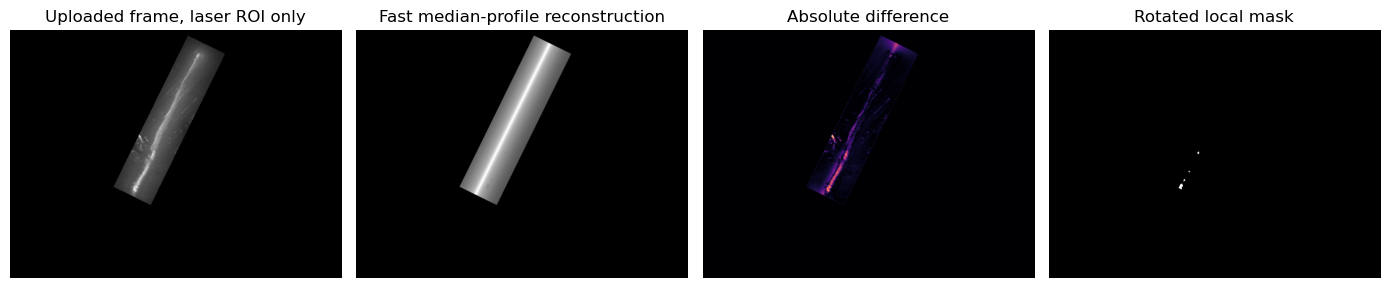

In [13]:

n = 4
plt.figure(figsize=(14, 5))
plt.subplot(1, n, 1)
plt.imshow(frame_roi, cmap='gray')
plt.title('Uploaded frame, laser ROI only')
plt.axis('off')

plt.subplot(1, n, 2)
plt.imshow(made, cmap='gray')
plt.title('Fast median-profile reconstruction')
plt.axis('off')

plt.subplot(1, n, 3)
plt.imshow(np.abs(diff), cmap='magma')
plt.title('Absolute difference')
plt.axis('off')
plt.tight_layout()
plt.subplot(1, n, 4)
plt.imshow(dbg['rotated_mask'], cmap='gray')
plt.title('Rotated local mask')
plt.axis('off')
plt.show()


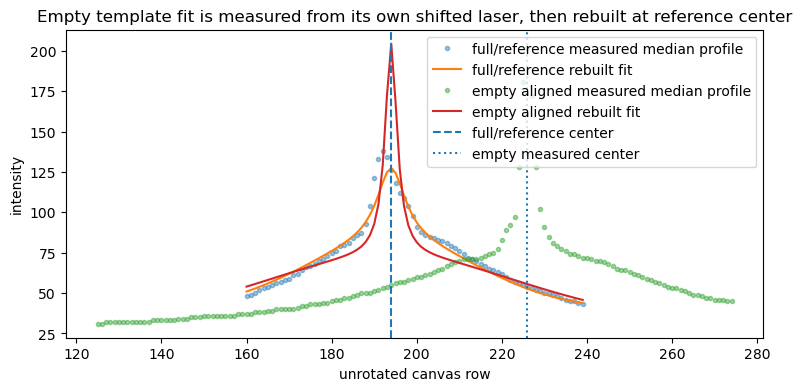

In [ ]:

plt.figure(figsize=(9, 4))
for label, fit_info in [('full/reference', dbg['full_fit']), ('empty aligned', dbg['empty_fit'])]:
    plt.plot(fit_info['x_pad'], fit_info['profile'], '.', alpha=0.45, label=f'{label} measured median profile')
    plt.plot(fit_info['x_canon'], fit_info['fit_profile'], '-', label=f'{label} rebuilt fit')

plt.axvline(dbg['full_fit']['measured_center'], linestyle='--', label='full/reference center')
if dbg['empty_fit']['target_center'] is not None:
    plt.axvline(dbg['empty_fit']['measured_center'], linestyle=':', label='empty measured center')

plt.xlabel('unrotated canvas row')
plt.ylabel('intensity')
plt.title('Empty template fit is measured from its own shifted laser, then rebuilt at reference center')
plt.legend()
plt.show()


## Mixed-mask example

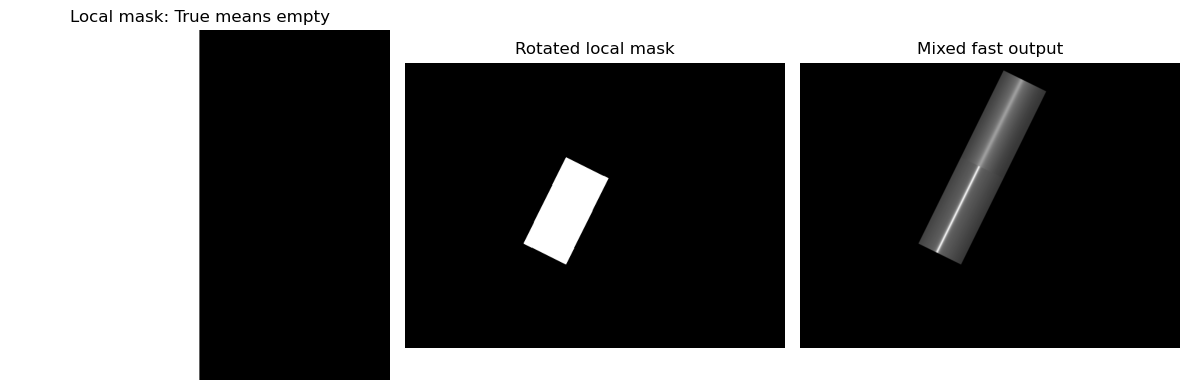

In [ ]:

# Example local bool mask in unrotated (w,l) coordinates.
# Default mask_true='empty': True = empty fit, False = full fit.
half_empty_mask = np.zeros((LASER_W, LASER_L), dtype=bool)
half_empty_mask[:, :LASER_L // 2] = True

mixed, mixed_dbg = make_laser_image(half_empty_mask, empty_template, full_template,
                                    mask_true='empty', background='zeros',
                                    fit_cache=cache, return_debug=True)

plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.imshow(half_empty_mask, cmap='gray', aspect='auto')
plt.title('Local mask: True means empty')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(mixed_dbg['rotated_mask'], cmap='gray')
plt.title('Rotated local mask')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(mixed, cmap='gray')
plt.title('Mixed fast output')
plt.axis('off')
plt.tight_layout()
plt.show()



## Notes

- The expensive part is still only two 1D fits: one empty profile and one full/reference profile.
- The reducer line is the key speed change: `profile = reducer(rect_pad, axis=-1)`.
- `empty_row_pad` lets the empty template be shifted while still being captured by the fit.
- `align_empty_to_full=True` fits the empty template at its actual measured center, then changes only the fitted `x0` before rebuilding the output profile.
- If the empty template is much farther away, increase `empty_row_pad`, for example `empty_row_pad=60`.
- If you already know the exact desired center, pass `target_empty_center=<row in unrotated canvas coordinates>`.
- Because the fit is one profile repeated along the laser length, it will not reproduce lengthwise brightness variation. That is intentional for speed and for making the template represent the general laser cross-section.
